In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [2]:
import seaborn as sns

In [3]:
from funs.analysis import (
    EmulatedDataStorage,
    Analysis)

In [4]:
working_dir = '/glade/work/qingyuany/gfdl_esm/'
case_name = "v1"
#para = pd.read_csv("/glade/work/qingyuany/cam7_tuning/cam7/para/ppe0_original_scale.csv", index_col=0)
#para = pd.read_csv("/glade/work/qingyuany/camml_re/v2/post_simulations/", index_col=0)
#para = xr.open_dataset('/glade/work/addisus/scam_scripts/PPE_250_ensemble/parameter38_100.nc').to_dataframe()
#para = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc').to_dataframe().drop(columns = 'Sample_nmb')


para = pd.read_csv("/glade/work/qingyuany/gfdl_esm/v0/PPE_input_parameters.csv", index_col=False)

#nc = xr.open_dataset('/glade/work/qingyuany/camml_re/v1/post_simulations/batch_v1.nc').ppe_ind

In [48]:
# working_dir = '/glade/work/qingyuany/camml_re/'
# case_name = "v1"
# para = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc').to_dataframe().drop(columns = 'Sample_nmb')
# para.index = para.index + 1


# nc = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/initial_ppe.nc')

In [48]:
%run ./funs/analysis.py
analysis = Analysis(working_dir, case_name, para, threshold_level=2.5)

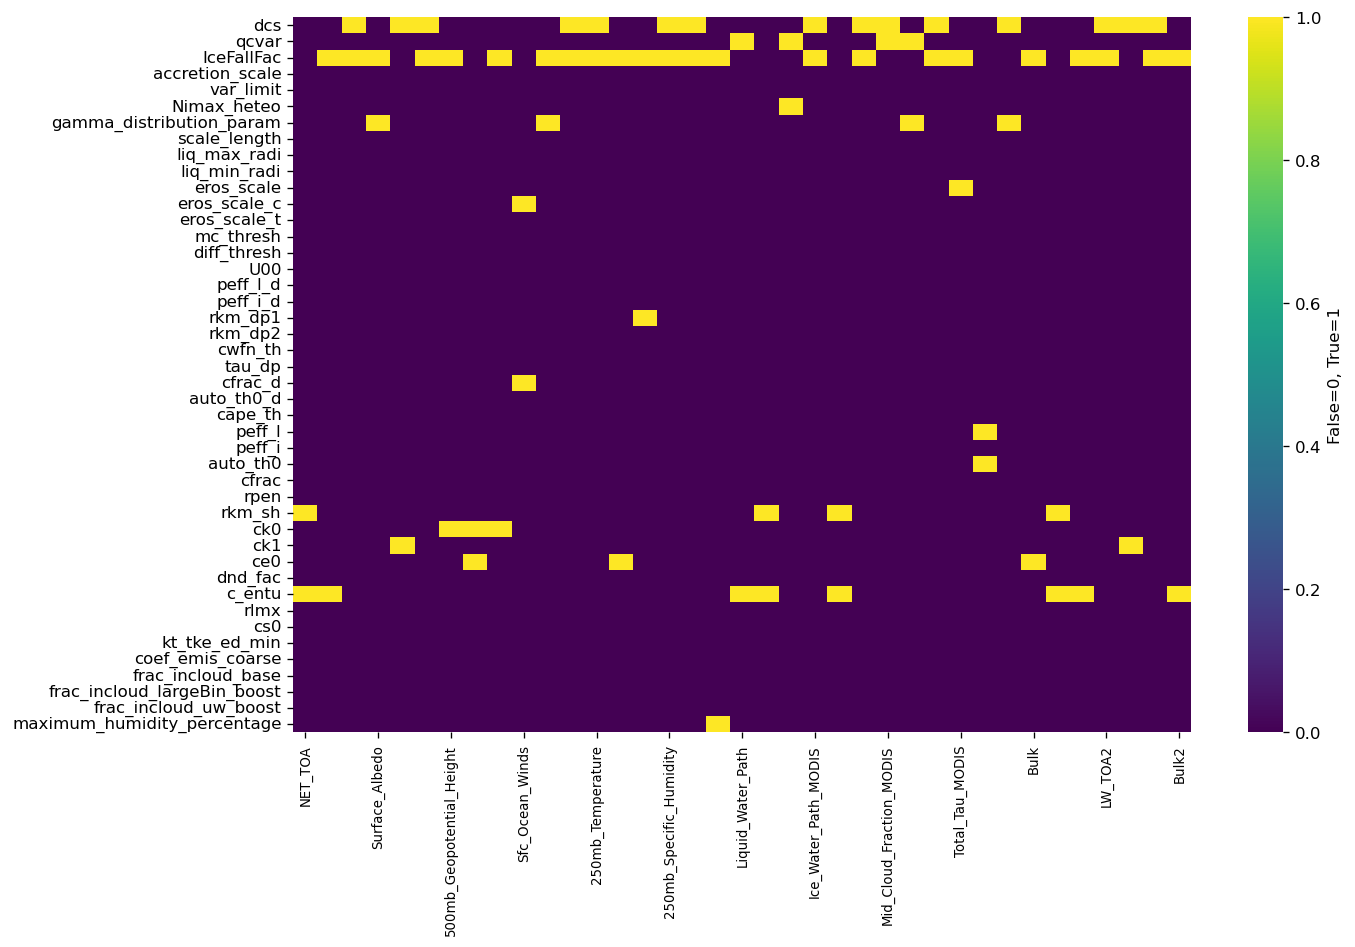

In [49]:
analysis.plot_onehot(figsize = (8, 6))

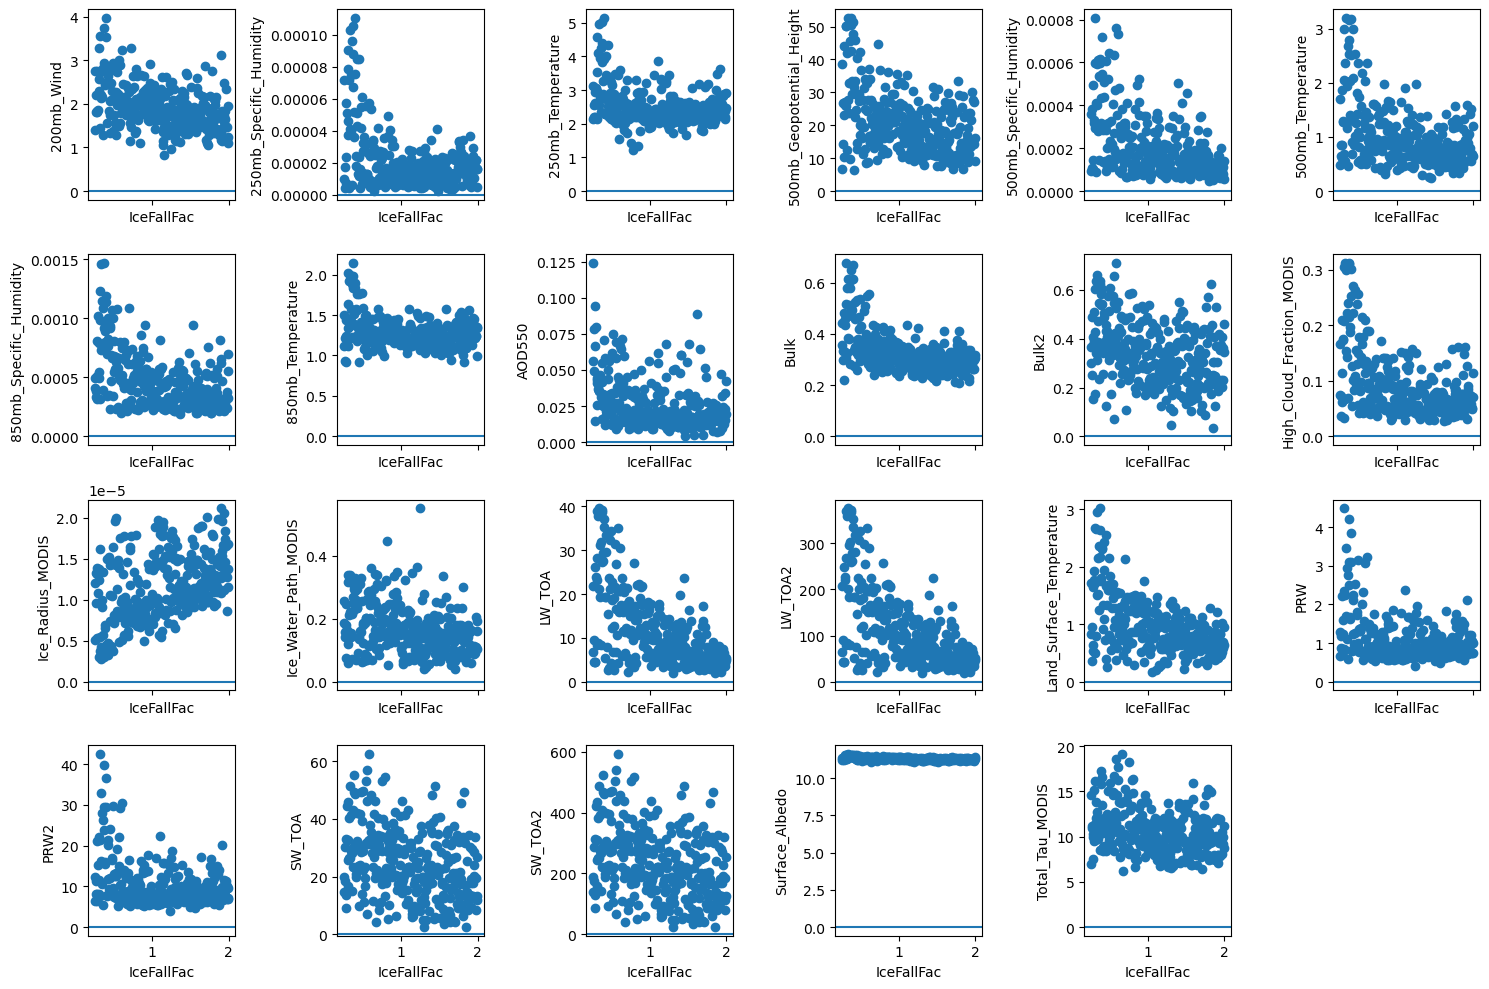

In [50]:
_ = analysis.plot_by_para('IceFallFac', ncols=6, figsize = (15,10))

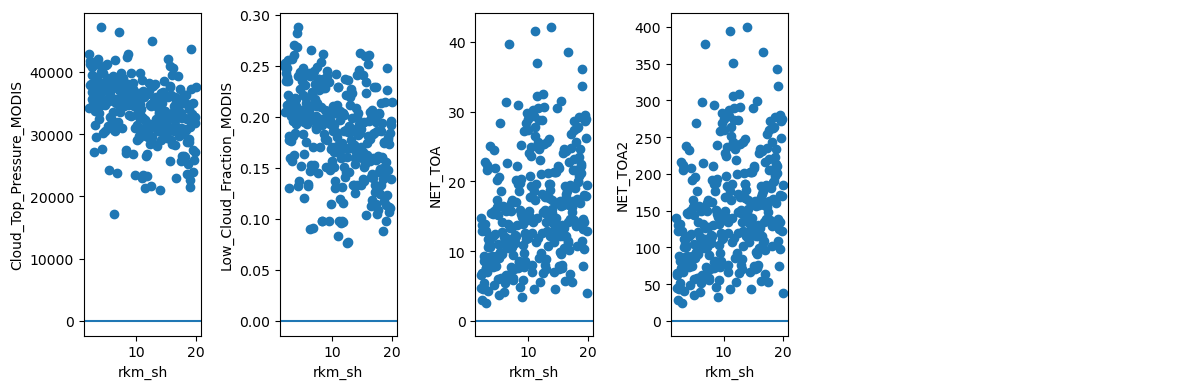

In [69]:
_ = analysis.plot_by_para('rkm_sh', ncols=6, figsize = (12,4))

In [52]:
for c in list(analysis.meta_onehot.index[analysis.meta_onehot['IceFallFac']]):
    
    temp_out = analysis.p_emu[analysis.tf_masks[c]].IceFallFac.min()
    print(f'{c:30}: {temp_out:3.2f},  {analysis.p_emu[analysis.tf_masks[c]].IceFallFac.shape[0]>5}')

SW_TOA                        : 0.00,  True
LW_TOA                        : 0.00,  True
Surface_Albedo                : nan,  False
PRW                           : 0.00,  True
500mb_Geopotential_Height     : 0.35,  True
200mb_Wind                    : nan,  False
850mb_Temperature             : nan,  False
500mb_Temperature             : 0.00,  True
250mb_Temperature             : nan,  False
850mb_Specific_Humidity       : 0.28,  True
500mb_Specific_Humidity       : 0.00,  True
250mb_Specific_Humidity       : 0.00,  True
Land_Surface_Temperature      : 0.00,  True
AOD550                        : 0.00,  True
Ice_Water_Path_MODIS          : 0.00,  True
High_Cloud_Fraction_MODIS     : 0.00,  True
Ice_Radius_MODIS              : 0.00,  True
Total_Tau_MODIS               : nan,  False
Bulk                          : nan,  False
SW_TOA2                       : 0.00,  True
LW_TOA2                       : 0.00,  True
PRW2                          : 0.00,  True
Bulk2                         : 

In [58]:
analysis.meta_onehot.index[analysis.meta_onehot['IceFallFac']]

Index(['SW_TOA', 'LW_TOA', 'Surface_Albedo', 'PRW',
       '500mb_Geopotential_Height', '200mb_Wind', '850mb_Temperature',
       '500mb_Temperature', '250mb_Temperature', '850mb_Specific_Humidity',
       '500mb_Specific_Humidity', '250mb_Specific_Humidity',
       'Land_Surface_Temperature', 'AOD550', 'Ice_Water_Path_MODIS',
       'High_Cloud_Fraction_MODIS', 'Ice_Radius_MODIS', 'Total_Tau_MODIS',
       'Bulk', 'SW_TOA2', 'LW_TOA2', 'PRW2', 'Bulk2'],
      dtype='object')

In [53]:
c = "500mb_Temperature"
analysis.p_emu[analysis.tf_masks[c]].IceFallFac.min()

4.899523583512533e-06

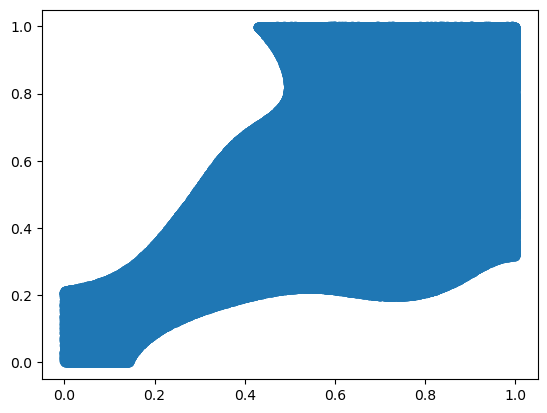

In [54]:
plt.scatter(analysis.p_emu[analysis.tf_masks[c]].IceFallFac, analysis.p_emu[analysis.tf_masks[c]].dcs)